In [2]:
import os
import pandas as pd

import torch
import torchvision

import matplotlib.pyplot as plt

In [3]:
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.9.1+cu126
Torchvision Version: 0.24.1+cu126


In [4]:
TEST_PATH  = "C:/Users/SAKTHI/Desktop/rework/data/fashion-mnist_test.csv"
TRAIN_PATH   = "C:/Users/SAKTHI/Desktop/rework/data/fashion-mnist_train.csv"

In [ ]:
# Load the variables safely

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# 28 × 28 = 784 pixels + 1 Label = 785 column
# Each pixel is stored as a number from **0 (black) to 255 (white)**.

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head(10)

Train shape: (60000, 785)
Test shape : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


In [6]:
# Fashion MNIST has 10 categories. Each label (0–9) corresponds to a clothing item.
CLASS_NAMES = [
    "T-shirt/top",  # 0
    "Trouser",      # 1
    "Pullover",     # 2
    "Dress",        # 3
    "Coat",         # 4
    "Sandal",       # 5
    "Shirt",        # 6
    "Sneaker",      # 7
    "Bag",          # 8
    "Ankle boot"    # 9
]

In [ ]:
plt.figure(figsize=(10, 4))
train_df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.xticks(range(10), CLASS_NAMES, rotation=45, ha='right')
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

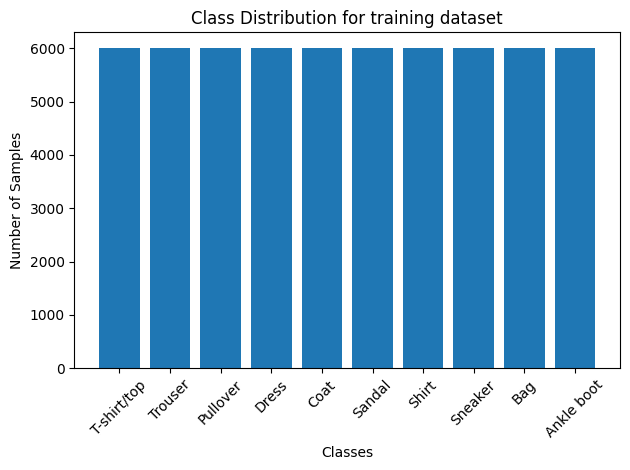

T-shirt/top - 6000
Trouser - 6000
Pullover - 6000
Dress - 6000
Coat - 6000
Sandal - 6000
Shirt - 6000
Sneaker - 6000
Bag - 6000
Ankle boot - 6000


In [14]:
# class distribution (to identify the balance or not)

plt.Figure(figsize=(10,4))

class_counts = train_df['label'].value_counts().sort_index()

plt.bar(class_counts.index, class_counts.values)

plt.xticks(class_counts.index, CLASS_NAMES, rotation=45)
plt.title("Class Distribution for training dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

for label, count in zip(class_counts.index, class_counts.values):
    print(CLASS_NAMES[label], "-", count)

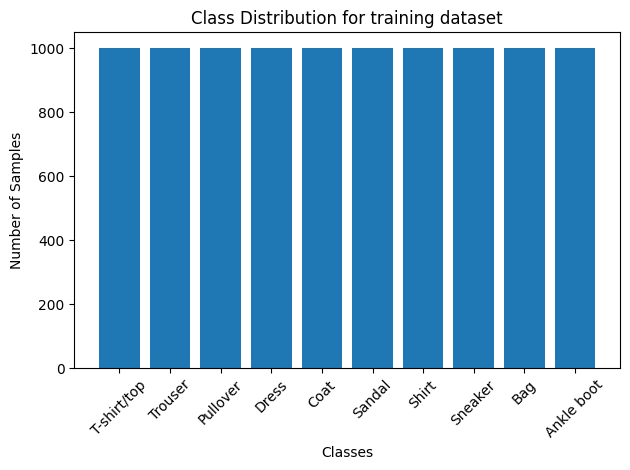

T-shirt/top - 1000
Trouser - 1000
Pullover - 1000
Dress - 1000
Coat - 1000
Sandal - 1000
Shirt - 1000
Sneaker - 1000
Bag - 1000
Ankle boot - 1000


In [15]:
# class distribution (to identify the balance or not)

plt.Figure(figsize=(10,4))

class_counts = test_df['label'].value_counts().sort_index()

plt.bar(class_counts.index, class_counts.values)

plt.xticks(class_counts.index, CLASS_NAMES, rotation=45)
plt.title("Class Distribution for training dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

for label, count in zip(class_counts.index, class_counts.values):
    print(CLASS_NAMES[label], "-", count)

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   4   0
   0   0   0   0  62  61  21  29  23  51 136  61   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0  88 201 228 225 255 115  62
 137 255 235 222 255 135   0   0   0   0   0   0   0   0   0   0   0   0
   0  47 252 234 238 224 215 215 229 108 180 207 214 224 231 249 254  45
   0   0   0   0   0   0   0   0   1   0   0 214 222 210 213 224 225 217
 220 254 233 219 221 217 223 221 240 254   0   0   1   0   0   0   1   0
   0   0 128 237 207 224 224 207 216 214 210 208 211 221 208 219 213 226
 211 237 150   0   0   0   0   0   0   2   0   0 237 222 215 207 210 212
 213 206 214 213 214 213 210 215 214 206 199 218 25

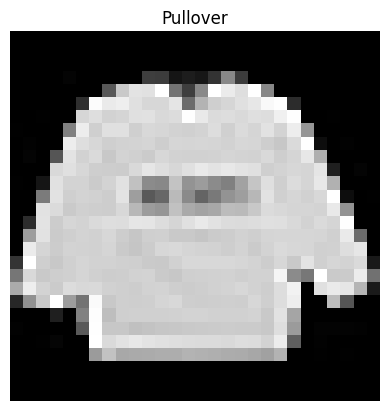

In [ ]:
# testing by loading a  1 image

# droping the label column and convert row into a NumPy array.
first_image = train_df.drop("label", axis=1).iloc[0].values
print(first_image)

# 1D(784,) into a 2D(28×28)

first_image = first_image.reshape(28, 28)
print("second",first_image)

label = train_df.iloc[0]["label"]

plt.imshow(first_image, cmap="gray")
plt.title(CLASS_NAMES[label])
plt.axis("off")
plt.show()

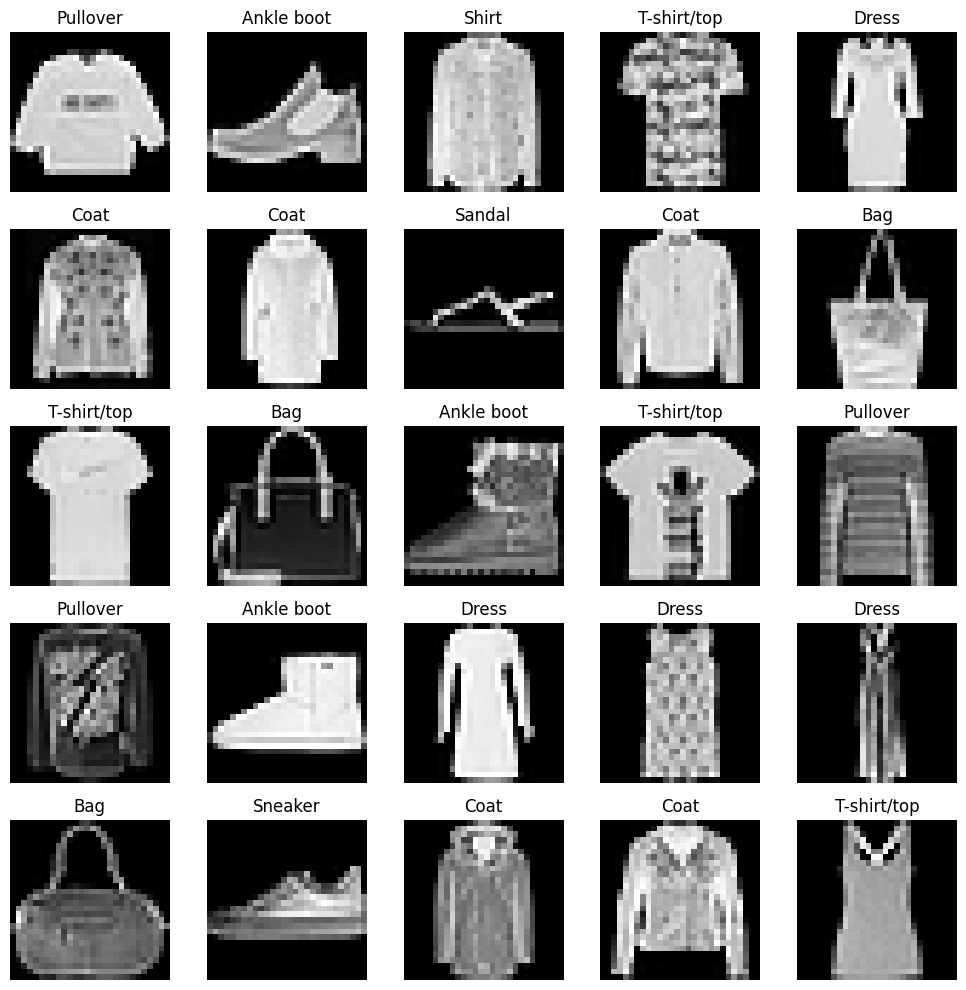

In [ ]:
# loading the other images

plt.figure(figsize=(10, 10))

for i in range(25):

    image = train_df.drop("label", axis=1).iloc[i].values
    image = image.reshape(28, 28)

    label = train_df.iloc[i]["label"]

    plt.subplot(5, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(CLASS_NAMES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()